# 🤖 AI Customer Support Performance Analysis
> **⚠️ Confidentiality Notice**  
> This project is based on real work completed at a previous employer.  
> The company name has been anonymised as **"Company X"** in accordance  
> with confidentiality obligations. All data presented here is either  
> synthetically generated or fully anonymised — no proprietary or  
> personally identifiable information has been disclosed.  
> The analytical approach, methodology, and code are entirely my own.
## Company X — Multi-Client Deployment Report
**Period:** January 2024 – June 2024  
**Author:** Data Analyst  
**Data:** 34,200 support tickets across 5 client companies in Russia

---
### Project Overview
**Company X**provides AI-powered customer support as a service — replacing human agents with intelligent bots across **phone, chat, email, and voice bot** channels.

This notebook evaluates the performance of 4 deployed AI agent versions across 5 client companies, based on:
- Ticket resolution rates & escalation to human agents
- Response times & interaction efficiency  
- Customer satisfaction (CSAT) & sentiment  
- Regional distribution & category-level diagnostics
- Temporal trends and model comparison

---


## 1. Environment Setup & Data Loading

In [1]:
# ── Standard imports ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#1A1D27',
    'axes.edgecolor':   '#2E3250',
    'axes.labelcolor':  '#C0C8E0',
    'xtick.color':      '#8890AA',
    'ytick.color':      '#8890AA',
    'text.color':       '#E0E4F0',
    'grid.color':       '#2E3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'figure.dpi':       130,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#1A1D27',
    'legend.edgecolor': '#2E3250',
})

# Palette — 4 agents
AGENT_COLORS = {
    'TargetAI Lite v1.0': '#F4845F',
    'TargetAI Lite v2.0': '#F5A623',
    'TargetAI Pro v2.0':  '#4FC3F7',
    'TargetAI Pro v3.0':  '#69F0AE',
}
COMPANY_COLORS = ['#7C6FFF','#F4845F','#4FC3F7','#F5A623','#69F0AE']
CHANNEL_COLORS = {'chat':'#7C6FFF','email':'#4FC3F7','phone':'#F4845F','voice_bot':'#69F0AE'}

print("✅  Libraries loaded successfully")
print(f"    pandas  {pd.__version__}  |  numpy  {np.__version__}  |  seaborn  {sns.__version__}")


✅  Libraries loaded successfully
    pandas  2.3.2  |  numpy  2.2.6  |  seaborn  0.13.2


In [2]:
# ── Load datasets ────────────────────────────────────────────────────────────
tickets   = pd.read_csv('data/tickets.csv',   parse_dates=['created_at','resolved_at'])
companies = pd.read_csv('data/companies.csv', parse_dates=['contract_start'])
agents    = pd.read_csv('data/ai_agents.csv', parse_dates=['release_date'])

# ── Feature engineering ──────────────────────────────────────────────────────
tickets['month']         = tickets['created_at'].dt.to_period('M')
tickets['week']          = tickets['created_at'].dt.isocalendar().week.astype(int)
tickets['hour']          = tickets['created_at'].dt.hour
tickets['day_of_week']   = tickets['created_at'].dt.day_name()
tickets['month_name']    = tickets['created_at'].dt.strftime('%b')

print(f"✅  Data loaded")
print(f"   tickets.csv   → {len(tickets):,} rows × {tickets.shape[1]} columns")
print(f"   companies.csv → {len(companies)} rows")
print(f"   ai_agents.csv → {len(agents)} rows")


✅  Data loaded
   tickets.csv   → 34,200 rows × 25 columns
   companies.csv → 5 rows
   ai_agents.csv → 4 rows


## 2. Data Overview

In [3]:
print("=== TICKETS — SCHEMA & SAMPLE ===")
tickets.info()


=== TICKETS — SCHEMA & SAMPLE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34200 entries, 0 to 34199
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ticket_id            34200 non-null  object        
 1   company_id           34200 non-null  object        
 2   company_name         34200 non-null  object        
 3   industry             34200 non-null  object        
 4   ai_agent_id          34200 non-null  object        
 5   ai_agent_name        34200 non-null  object        
 6   agent_tier           34200 non-null  object        
 7   channel              34200 non-null  object        
 8   category             34200 non-null  object        
 9   region               34200 non-null  object        
 10  created_at           34200 non-null  datetime64[ns]
 11  resolved_at          34200 non-null  datetime64[ns]
 12  resolution_time_min  34200 non-null  int64         
 1

In [4]:
tickets.head(3)


,ticket_id,company_id,company_name,industry,ai_agent_id,ai_agent_name,agent_tier,channel,category,region,...,was_escalated,resolution_status,customer_sentiment,satisfaction_score,complexity_flag,month,week,hour,day_of_week,month_name
0,TKT-C001-00001,C001,NovaTelecom,Telecommunications,AGT-PRO-2,TargetAI Pro v2.0,Pro,email,number_porting,Moscow,...,False,resolved_by_ai,positive,5.0,False,2024-06,24,3,Wednesday,Jun
1,TKT-C001-00002,C001,NovaTelecom,Telecommunications,AGT-PRO-2,TargetAI Pro v2.0,Pro,phone,billing_dispute,Rostov-on-Don,...,False,resolved_by_ai,positive,5.0,False,2024-01,2,2,Monday,Jan
2,TKT-C001-00003,C001,NovaTelecom,Telecommunications,AGT-PRO-2,TargetAI Pro v2.0,Pro,chat,device_support,Chelyabinsk,...,False,resolved_by_ai,positive,3.0,False,2024-03,11,0,Tuesday,Mar


In [5]:
print("=== MISSING VALUES ===")
missing = tickets.isnull().sum()
missing = missing[missing > 0]
print(missing)
print(f"\n⚠️  satisfaction_score is intentionally ~30% missing")
print("   (not all customers fill in the rating — realistic behaviour)\n")

print("=== BASIC STATISTICS ===")
tickets[['resolution_time_min','first_response_sec','interaction_turns','satisfaction_score']].describe().round(2)


=== MISSING VALUES ===
satisfaction_score    10288
dtype: int64

⚠️  satisfaction_score is intentionally ~30% missing
   (not all customers fill in the rating — realistic behaviour)

=== BASIC STATISTICS ===


,resolution_time_min,first_response_sec,interaction_turns,satisfaction_score
count,34200.00,34200.00,34200.00,23912.00
mean,32.54,9.64,4.86,3.64
std,30.10,5.86,2.59,1.21
min,1.00,1.00,1.00,1.00
25%,14.00,6.00,3.00,3.00
50%,24.00,8.00,5.00,4.00
75%,40.00,12.00,7.00,5.00
max,486.00,41.00,12.00,5.00


## 3. High-Level KPIs — Executive Dashboard

In [12]:
from IPython.display import display, HTML

# ── Compute KPIs ──────────────────────────────────────────────────────────────
total_tickets  = len(tickets)
resolved_by_ai = (tickets['resolution_status'] == 'resolved_by_ai').sum()
escalated      = (tickets['resolution_status'] == 'escalated_to_human').sum()
ai_res_rate    = resolved_by_ai / total_tickets * 100
esc_rate       = escalated / total_tickets * 100
avg_resp       = tickets['first_response_sec'].mean()
avg_res_time   = tickets['resolution_time_min'].mean()
avg_csat       = tickets['satisfaction_score'].mean()
positive_share = (tickets['customer_sentiment'] == 'positive').mean() * 100

html = """
<div style="display:grid; grid-template-columns:repeat(4,1fr); gap:12px; padding:10px; background:#0F1117;">
"""

kpi_items = [
    ("📋", "Total Tickets",       f"{total_tickets:,}"),
    ("✅", "AI Resolution Rate",  f"{ai_res_rate:.1f}%"),
    ("⚠️", "Escalation Rate",     f"{esc_rate:.1f}%"),
    ("⚡", "Avg First Response",  f"{avg_resp:.1f}s"),
    ("⏱️", "Avg Resolution Time", f"{avg_res_time:.0f} min"),
    ("⭐", "Avg CSAT Score",      f"{avg_csat:.2f}/5"),
    ("😊", "Positive Sentiment",  f"{positive_share:.1f}%"),
    ("🏢", "Client Companies",    "5"),
]

for icon, label, value in kpi_items:
    html += f"""
    <div style="background:#1E2235; border:1px solid #3A3F60; border-radius:12px;
                padding:20px; text-align:center;">
        <div style="font-size:28px; margin-bottom:8px;">{icon}</div>
        <div style="font-size:22px; font-weight:bold; color:#69F0AE;">{value}</div>
        <div style="font-size:11px; color:#8890AA; margin-top:6px;">{label}</div>
    </div>"""

html += "</div>"
display(HTML(html))

## 4. AI Agent Performance Comparison

In [14]:
# ── Per-agent summary ────────────────────────────────────────────────────────
agent_stats = tickets.groupby('ai_agent_name').agg(
    total_tickets       = ('ticket_id',            'count'),
    escalation_rate     = ('was_escalated',         'mean'),
    avg_response_sec    = ('first_response_sec',    'mean'),
    avg_resolution_min  = ('resolution_time_min',   'mean'),
    avg_csat            = ('satisfaction_score',    'mean'),
    avg_turns           = ('interaction_turns',     'mean'),
    positive_sentiment  = ('customer_sentiment',
                           lambda x: (x == 'positive').mean()),
).reset_index()

agent_stats['resolution_rate'] = 1 - agent_stats['escalation_rate']
agent_stats = agent_stats.sort_values('resolution_rate', ascending=False)
agent_stats.round(3)


,ai_agent_name,total_tickets,escalation_rate,avg_response_sec,avg_resolution_min,avg_csat,avg_turns,positive_sentiment,resolution_rate
3,TargetAI Pro v3.0,8400,0.104,5.489,31.531,3.715,4.785,0.557,0.896
2,TargetAI Pro v2.0,17400,0.140,8.533,31.563,3.656,4.853,0.536,0.860
1,TargetAI Lite v2.0,3000,0.196,13.601,35.304,3.553,4.889,0.501,0.804
0,TargetAI Lite v1.0,5400,0.221,17.489,35.723,3.547,5.013,0.503,0.779


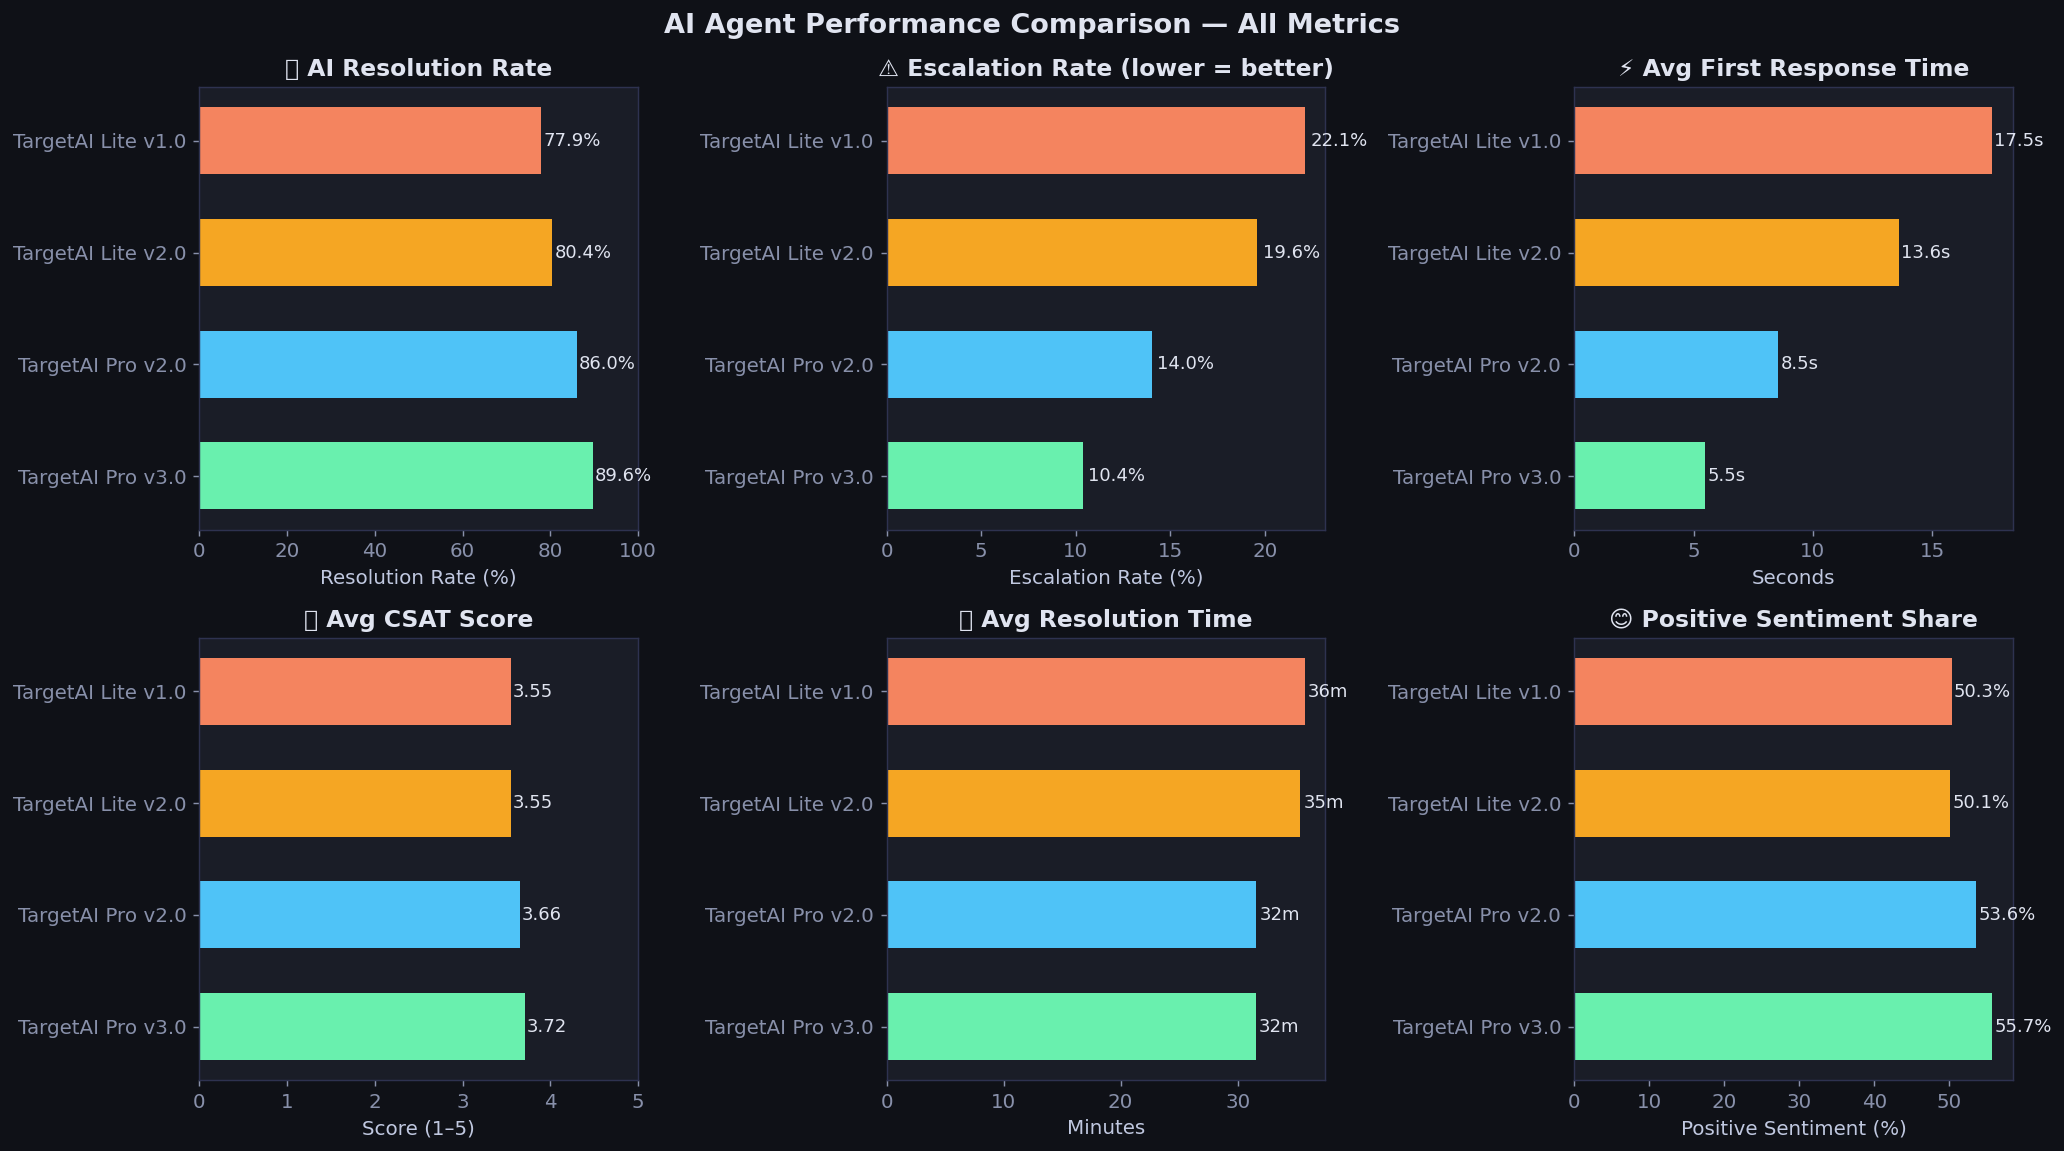

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('AI Agent Performance Comparison — All Metrics', fontsize=15, fontweight='bold')

agents_order = agent_stats['ai_agent_name'].tolist()
colors = [AGENT_COLORS[a] for a in agents_order]

# 1. Resolution rate
ax = axes[0, 0]
bars = ax.barh(agents_order, agent_stats['resolution_rate']*100, color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Resolution Rate (%)')
ax.set_title('✅ AI Resolution Rate')
ax.set_xlim(0, 100)
for bar, v in zip(bars, agent_stats['resolution_rate']*100):
    ax.text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

# 2. Escalation rate
ax = axes[0, 1]
bars = ax.barh(agents_order, agent_stats['escalation_rate']*100, color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Escalation Rate (%)')
ax.set_title('⚠️ Escalation Rate (lower = better)')
for bar, v in zip(bars, agent_stats['escalation_rate']*100):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

# 3. Avg first response
ax = axes[0, 2]
bars = ax.barh(agents_order, agent_stats['avg_response_sec'], color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Seconds')
ax.set_title('⚡ Avg First Response Time')
for bar, v in zip(bars, agent_stats['avg_response_sec']):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}s', va='center', fontsize=10)

# 4. Avg CSAT
ax = axes[1, 0]
bars = ax.barh(agents_order, agent_stats['avg_csat'], color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Score (1–5)')
ax.set_title('⭐ Avg CSAT Score')
ax.set_xlim(0, 5)
for bar, v in zip(bars, agent_stats['avg_csat']):
    ax.text(v+0.02, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=10)

# 5. Avg resolution time
ax = axes[1, 1]
bars = ax.barh(agents_order, agent_stats['avg_resolution_min'], color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Minutes')
ax.set_title('⏱️ Avg Resolution Time')
for bar, v in zip(bars, agent_stats['avg_resolution_min']):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.0f}m', va='center', fontsize=10)

# 6. Positive sentiment
ax = axes[1, 2]
bars = ax.barh(agents_order, agent_stats['positive_sentiment']*100, color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Positive Sentiment (%)')
ax.set_title('😊 Positive Sentiment Share')
for bar, v in zip(bars, agent_stats['positive_sentiment']*100):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('agent_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


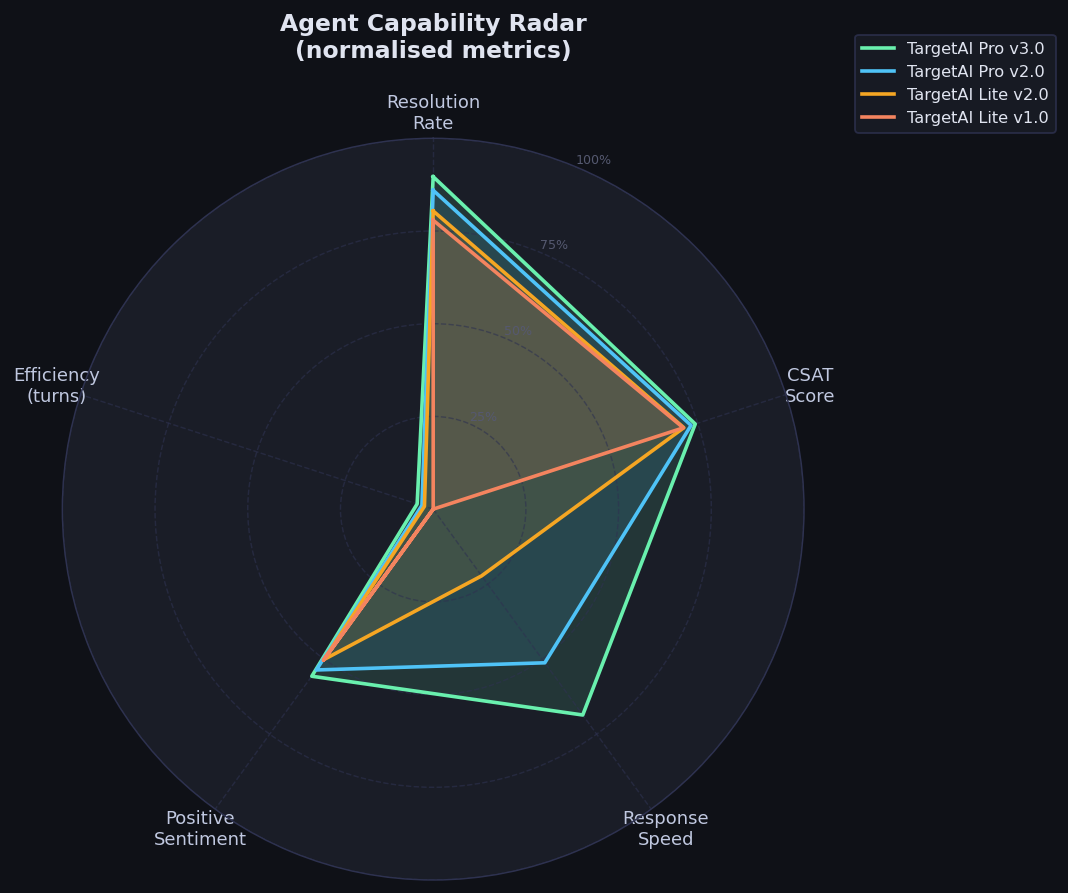

In [16]:
# ── Spider / Radar chart — agent strengths ───────────────────────────────────
from matplotlib.patches import Polygon
import matplotlib.patheffects as pe

metrics_raw = {
    'Resolution\nRate':   agent_stats['resolution_rate'].values,
    'CSAT\nScore':        agent_stats['avg_csat'].values / 5,
    'Response\nSpeed':    1 - (agent_stats['avg_response_sec'].values /
                                agent_stats['avg_response_sec'].max()),
    'Positive\nSentiment': agent_stats['positive_sentiment'].values,
    'Efficiency\n(turns)':  1 - (agent_stats['avg_turns'].values /
                                  agent_stats['avg_turns'].max()),
}
labels  = list(metrics_raw.keys())
N       = len(labels)
angles  = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True),
                       facecolor='#0F1117')
ax.set_facecolor('#1A1D27')
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10, color='#C0C8E0')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], size=7, color='#555970')
ax.grid(color='#2E3250', linestyle='--', alpha=0.6)

for i, agent_name in enumerate(agents_order):
    vals = [list(metrics_raw[m])[i] for m in labels]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, linestyle='solid',
            color=AGENT_COLORS[agent_name], label=agent_name)
    ax.fill(angles, vals, alpha=0.12, color=AGENT_COLORS[agent_name])

ax.set_title('Agent Capability Radar\n(normalised metrics)', size=13,
             fontweight='bold', pad=20, color='#E0E4F0')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('agent_radar.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 5. Escalation Analysis

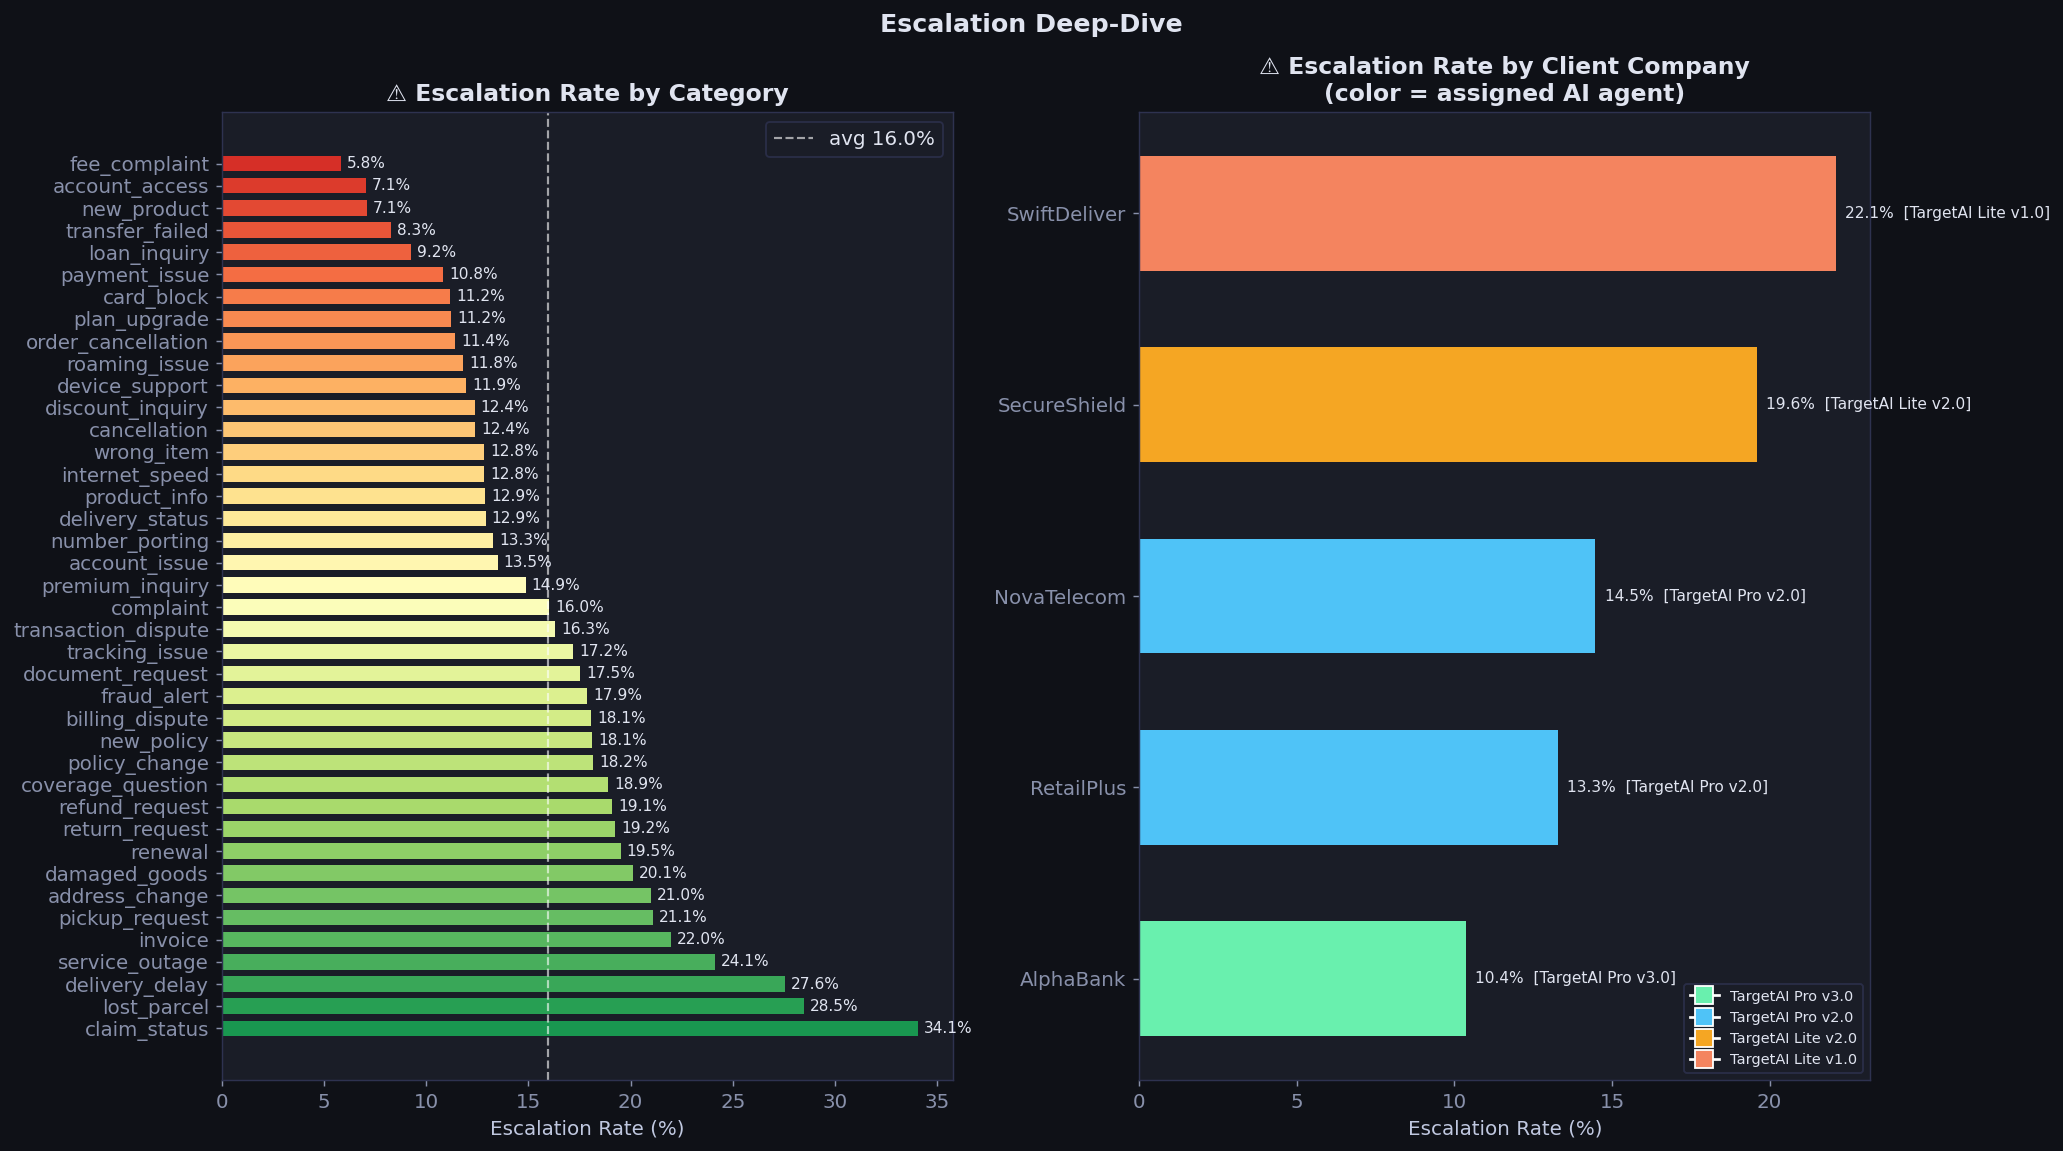

In [22]:
# ── Escalation rate by category ──────────────────────────────────────────────
cat_esc = (tickets.groupby('category')['was_escalated']
           .agg(['mean','count'])
           .rename(columns={'mean':'esc_rate','count':'total'})
           .sort_values('esc_rate', ascending=False)
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle('Escalation Deep-Dive', fontsize=14, fontweight='bold')

# Left: by category
ax = axes[0]
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(cat_esc)))
bars = ax.barh(cat_esc['category'], cat_esc['esc_rate']*100, color=palette,
               edgecolor='none', height=0.7)
ax.axvline(cat_esc['esc_rate'].mean()*100, color='white', linestyle='--',
           linewidth=1.2, alpha=0.6, label=f"avg {cat_esc['esc_rate'].mean()*100:.1f}%")
ax.set_xlabel('Escalation Rate (%)')
ax.set_title('⚠️ Escalation Rate by Category')
ax.legend()
for bar, v in zip(bars, cat_esc['esc_rate']*100):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=8.5)

# Right: by company
comp_esc = (tickets.groupby(['company_name','ai_agent_name'])['was_escalated']
            .mean().reset_index())
comp_esc.columns = ['company','agent','esc_rate']
comp_esc = comp_esc.sort_values('esc_rate')

bar_colors = [AGENT_COLORS[a] for a in comp_esc['agent']]
ax = axes[1]
bars = ax.barh(comp_esc['company'], comp_esc['esc_rate']*100,
               color=bar_colors, edgecolor='none', height=0.6)
ax.set_xlabel('Escalation Rate (%)')
ax.set_title('⚠️ Escalation Rate by Client Company\n(color = assigned AI agent)')
for bar, (v, ag) in zip(bars, zip(comp_esc['esc_rate']*100, comp_esc['agent'])):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%  [{ag}]', va='center', fontsize=8.5)

# legend
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker='s', color='w',
                         markerfacecolor=AGENT_COLORS[a], markersize=10, label=a)
                  for a in agents_order]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('escalation_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


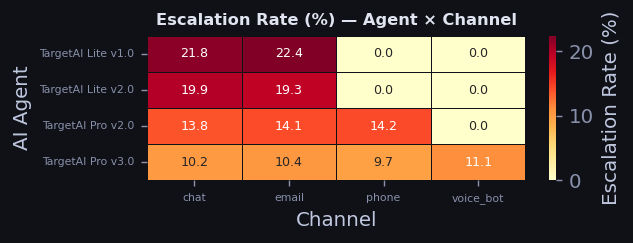

In [38]:
# ── Escalation by channel × agent (heatmap) ──────────────────────────────────
pivot = (tickets.groupby(['ai_agent_name','channel'])['was_escalated']
         .mean().unstack(fill_value=0) * 100)

fig, ax = plt.subplots(figsize=(5, 2))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0F1117',
            annot_kws={'size':7},
            cbar_kws={'label':'Escalation Rate (%)'}, ax=ax)
ax.set_title('Escalation Rate (%) — Agent × Channel', fontsize=9, fontweight='bold')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Channel'); ax.set_ylabel('AI Agent')
plt.tight_layout()
plt.savefig('escalation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 6. Temporal Trends

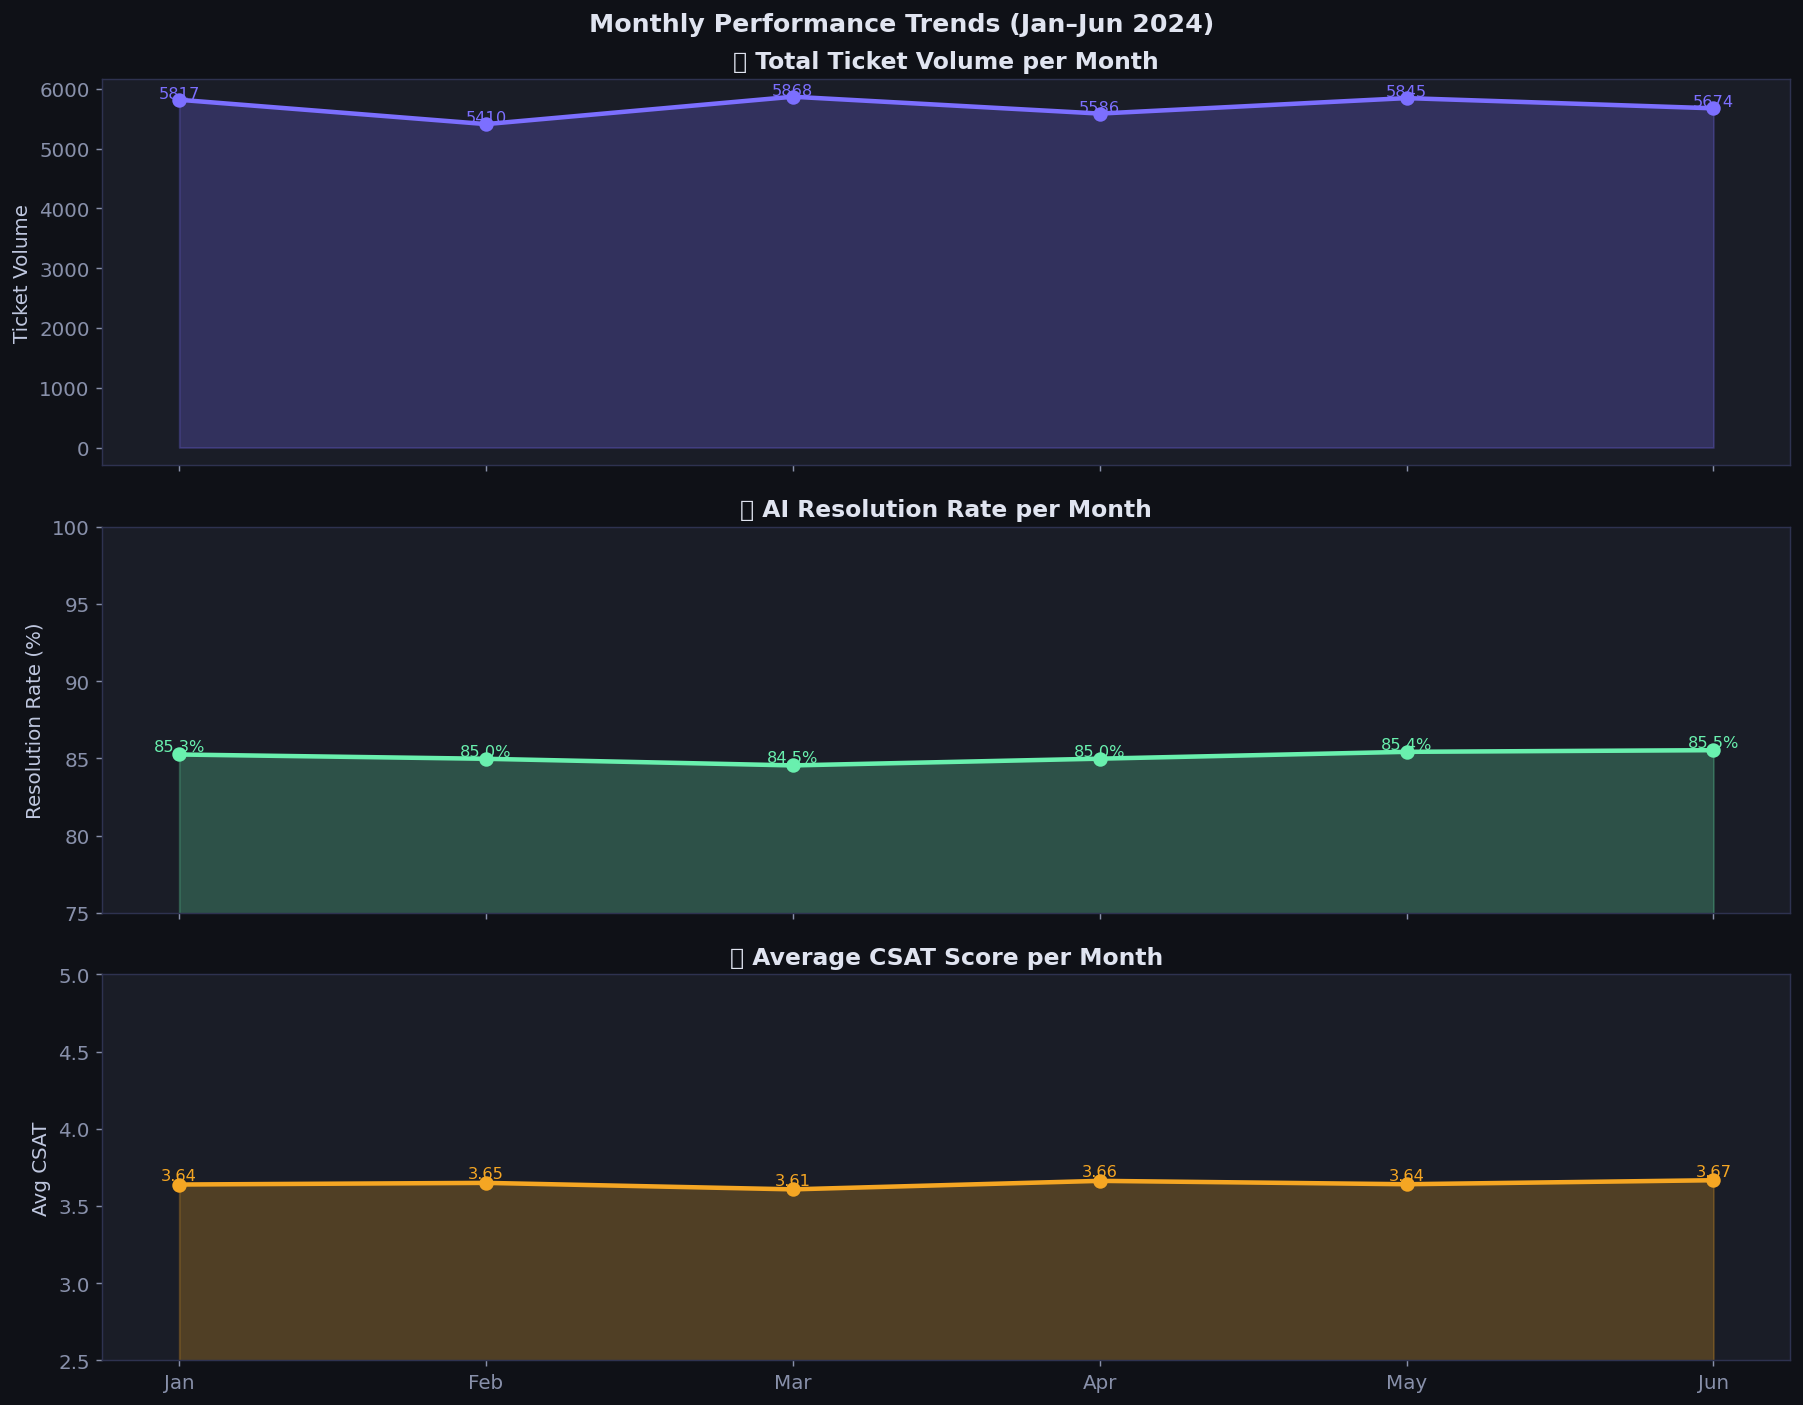

In [39]:
# ── Monthly volume & resolution rate ────────────────────────────────────────
monthly = (tickets.groupby('month').agg(
    tickets       = ('ticket_id','count'),
    escalated     = ('was_escalated','sum'),
    avg_csat      = ('satisfaction_score','mean'),
    avg_resp      = ('first_response_sec','mean'),
).reset_index())
monthly['resolution_rate'] = (monthly['tickets'] - monthly['escalated']) / monthly['tickets'] * 100
monthly['month_str'] = monthly['month'].astype(str).str[-5:]   # 01, 02 …

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Monthly Performance Trends (Jan–Jun 2024)', fontsize=14, fontweight='bold')
months_x = range(len(monthly))

# Volume
ax = axes[0]
ax.fill_between(months_x, monthly['tickets'], alpha=0.25, color='#7C6FFF')
ax.plot(months_x, monthly['tickets'], color='#7C6FFF', linewidth=2.5, marker='o', markersize=7)
ax.set_ylabel('Ticket Volume')
ax.set_title('📋 Total Ticket Volume per Month')
for x, y in zip(months_x, monthly['tickets']):
    ax.text(x, y+30, str(y), ha='center', fontsize=9, color='#7C6FFF')

# Resolution rate
ax = axes[1]
ax.fill_between(months_x, monthly['resolution_rate'], alpha=0.25, color='#69F0AE')
ax.plot(months_x, monthly['resolution_rate'], color='#69F0AE', linewidth=2.5, marker='o', markersize=7)
ax.set_ylabel('Resolution Rate (%)')
ax.set_title('✅ AI Resolution Rate per Month')
ax.set_ylim(75, 100)
for x, y in zip(months_x, monthly['resolution_rate']):
    ax.text(x, y+0.2, f'{y:.1f}%', ha='center', fontsize=9, color='#69F0AE')

# CSAT
ax = axes[2]
ax.fill_between(months_x, monthly['avg_csat'], alpha=0.25, color='#F5A623')
ax.plot(months_x, monthly['avg_csat'], color='#F5A623', linewidth=2.5, marker='o', markersize=7)
ax.set_ylabel('Avg CSAT')
ax.set_title('⭐ Average CSAT Score per Month')
ax.set_ylim(2.5, 5)
ax.set_xticks(months_x)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun'])
for x, y in zip(months_x, monthly['avg_csat']):
    ax.text(x, y+0.03, f'{y:.2f}', ha='center', fontsize=9, color='#F5A623')

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


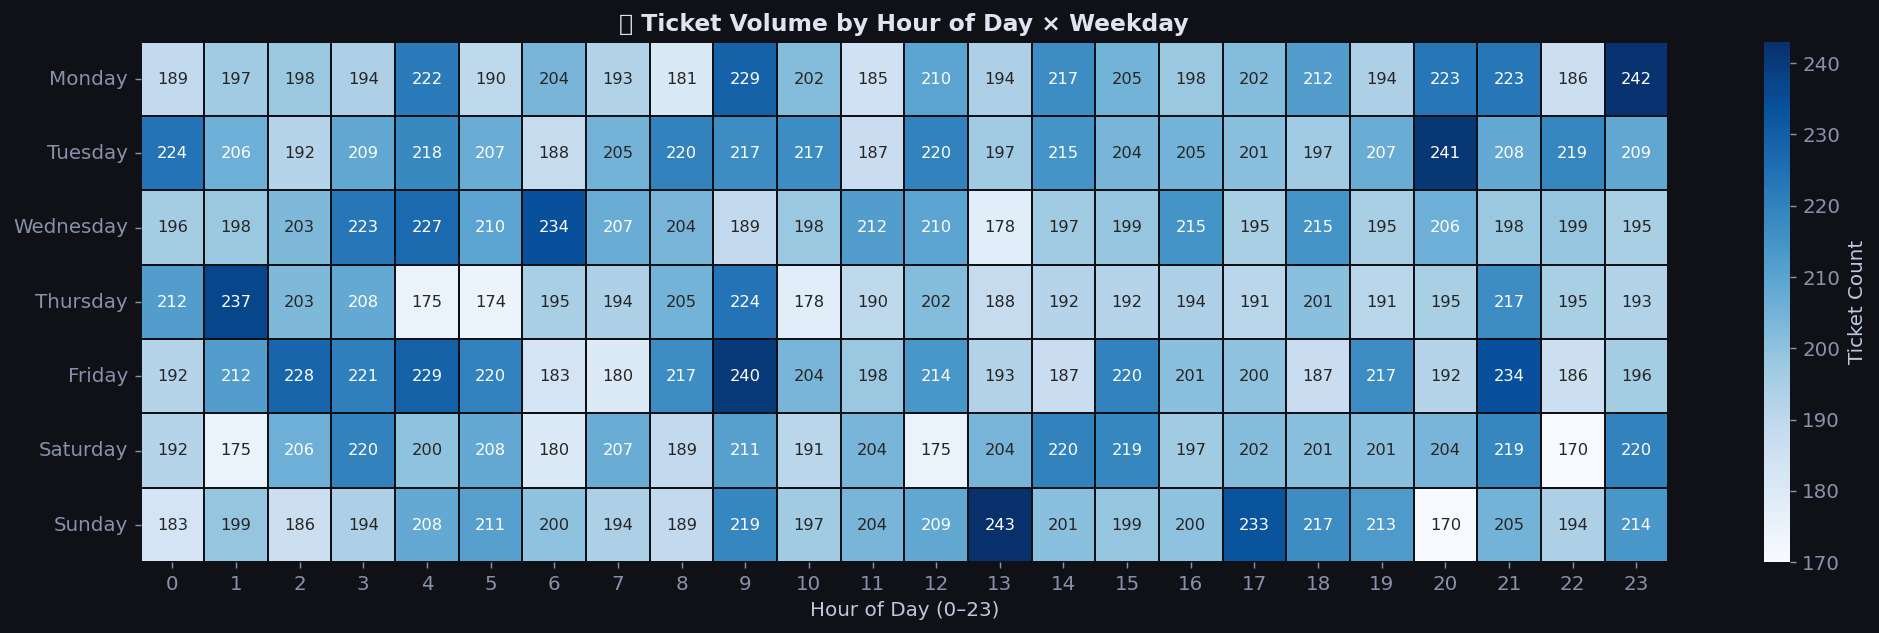

In [40]:
# ── Heatmap: ticket volume by hour × weekday ─────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = (tickets.groupby(['day_of_week','hour'])['ticket_id']
        .count().unstack(fill_value=0))
heat = heat.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat, cmap='Blues', linewidths=0.2, linecolor='#0F1117',
            ax=ax,annot=True, fmt='d', annot_kws={'size': 9}, cbar_kws={'label':'Ticket Count'})
ax.set_title('🕐 Ticket Volume by Hour of Day × Weekday', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (0–23)');  ax.set_ylabel('')
plt.tight_layout()
plt.savefig('hourly_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 7. Regional Analysis

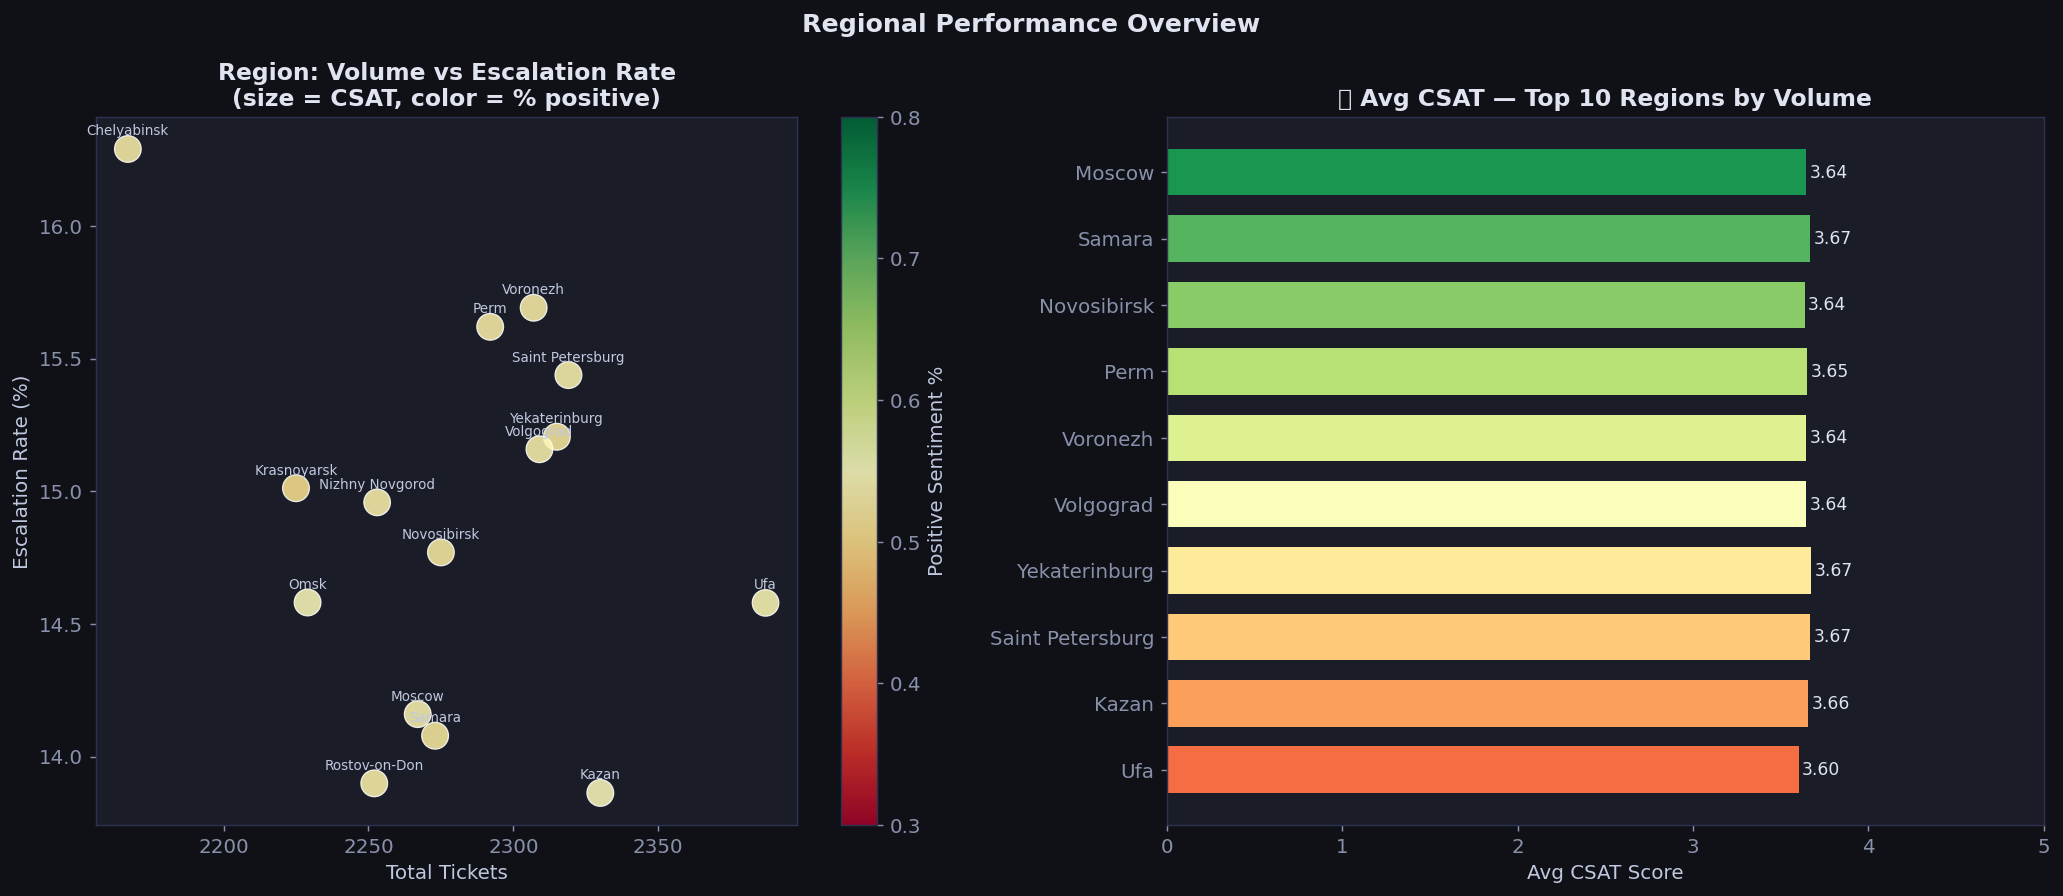

In [41]:
# ── Top regions by volume & escalation rate ──────────────────────────────────
region_stats = (tickets.groupby('region').agg(
    total        = ('ticket_id','count'),
    esc_rate     = ('was_escalated','mean'),
    avg_csat     = ('satisfaction_score','mean'),
    positive_pct = ('customer_sentiment', lambda x: (x=='positive').mean()),
).reset_index().sort_values('total', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold')

# Bubble chart: volume vs escalation
ax = axes[0]
scatter = ax.scatter(
    region_stats['total'],
    region_stats['esc_rate'] * 100,
    s=region_stats['avg_csat'] * 60,
    c=region_stats['positive_pct'],
    cmap='RdYlGn', vmin=0.3, vmax=0.8,
    alpha=0.85, edgecolors='white', linewidths=0.7
)
for _, row in region_stats.iterrows():
    ax.annotate(row['region'], (row['total'], row['esc_rate']*100),
                fontsize=7.5, ha='center', va='bottom', color='#C0C8E0',
                xytext=(0, 6), textcoords='offset points')
ax.set_xlabel('Total Tickets')
ax.set_ylabel('Escalation Rate (%)')
ax.set_title('Region: Volume vs Escalation Rate\n(size = CSAT, color = % positive)')
plt.colorbar(scatter, ax=ax, label='Positive Sentiment %')

# Bar: avg CSAT top-10
ax = axes[1]
top10 = region_stats.head(10)
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top10)))
bars = ax.barh(top10['region'], top10['avg_csat'], color=colors_bar,
               edgecolor='none', height=0.7)
ax.set_xlabel('Avg CSAT Score')
ax.set_title('⭐ Avg CSAT — Top 10 Regions by Volume')
ax.set_xlim(0, 5)
for bar, v in zip(bars, top10['avg_csat']):
    ax.text(v+0.02, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9.5)

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 8. Customer Satisfaction & Sentiment Analysis

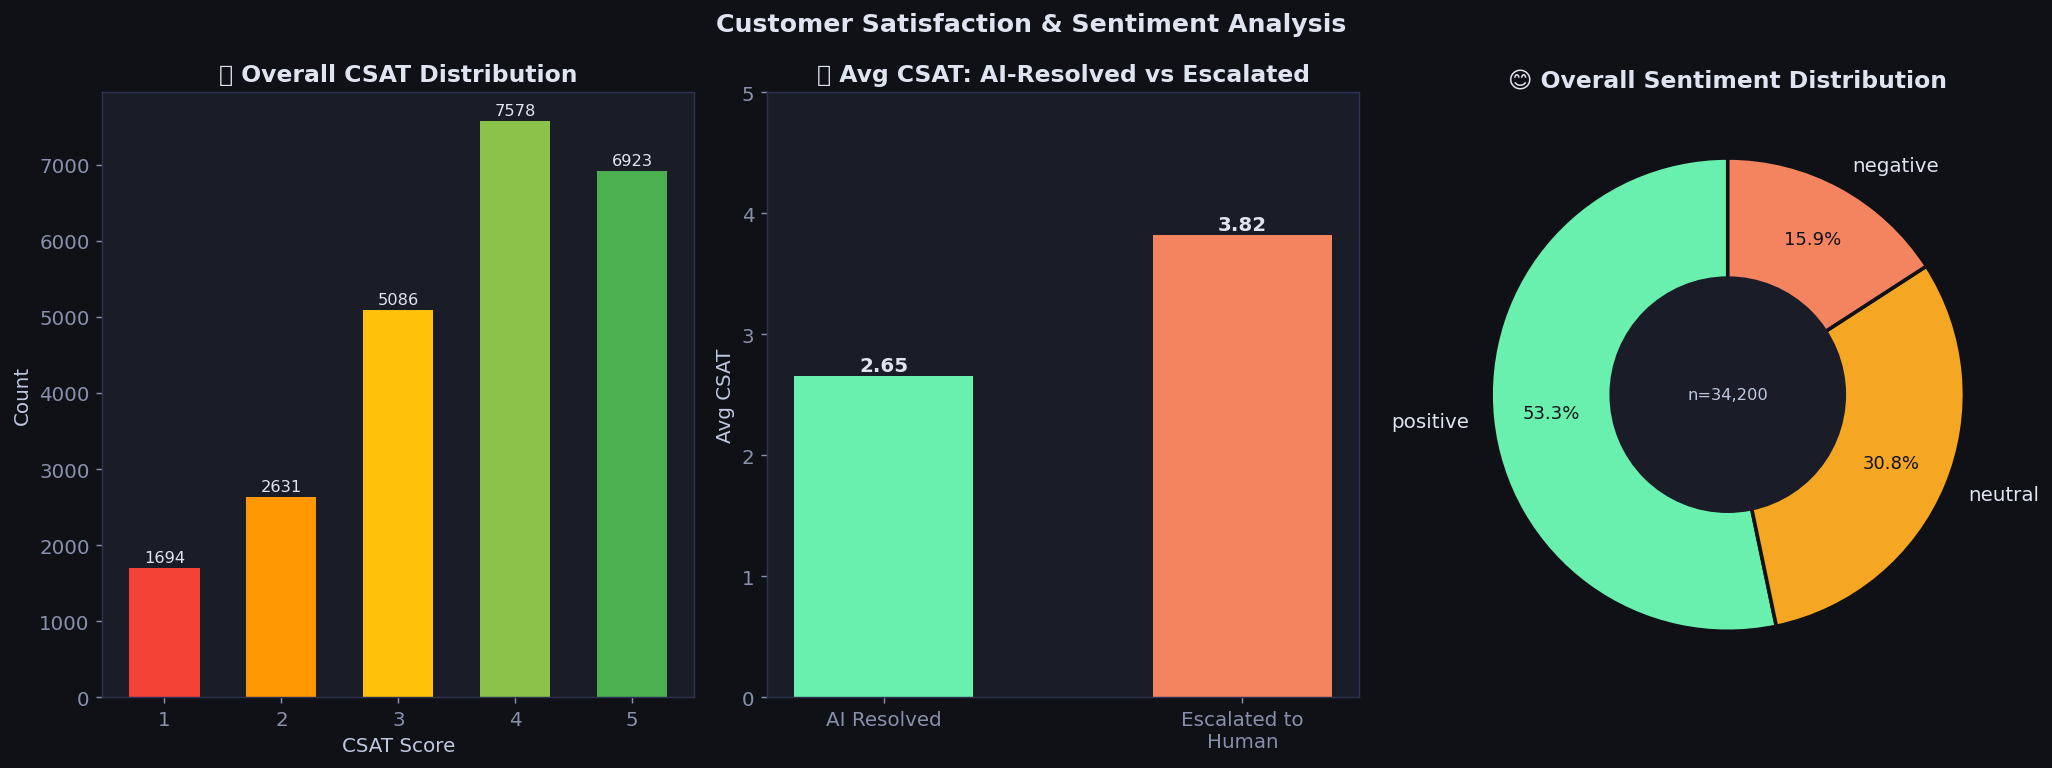

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Customer Satisfaction & Sentiment Analysis', fontsize=14, fontweight='bold')

# CSAT distribution
ax = axes[0]
csat_counts = tickets['satisfaction_score'].dropna().value_counts().sort_index()
bar_colors  = ['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50']
bars = ax.bar(csat_counts.index, csat_counts.values, color=bar_colors,
              edgecolor='none', width=0.6)
ax.set_xlabel('CSAT Score'); ax.set_ylabel('Count')
ax.set_title('⭐ Overall CSAT Distribution')
for bar, v in zip(bars, csat_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+80, str(v),
            ha='center', fontsize=9)

# CSAT by resolution status
ax = axes[1]
csat_by_res = tickets.groupby('resolution_status')['satisfaction_score'].mean()
colors_res  = ['#69F0AE','#F4845F']
bars = ax.bar(csat_by_res.index, csat_by_res.values,
              color=colors_res, edgecolor='none', width=0.5)
ax.set_ylim(0, 5);  ax.set_ylabel('Avg CSAT')
ax.set_title('⭐ Avg CSAT: AI-Resolved vs Escalated')
labels_res = ['AI Resolved', 'Escalated to\nHuman']
ax.set_xticks([0,1]); ax.set_xticklabels(labels_res)
for bar, v in zip(bars, csat_by_res.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.04,
            f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Sentiment donut
ax = axes[2]
sent_counts = tickets['customer_sentiment'].value_counts()
sent_colors = {'positive':'#69F0AE','neutral':'#F5A623','negative':'#F4845F'}
colors_sent = [sent_colors[s] for s in sent_counts.index]
wedges, texts, autotexts = ax.pie(
    sent_counts.values, labels=sent_counts.index,
    autopct='%1.1f%%', colors=colors_sent,
    startangle=90, pctdistance=0.75,
    wedgeprops={'linewidth':2,'edgecolor':'#0F1117'},
)
for t in autotexts: t.set_fontsize(10); t.set_color('#0F1117')
centre = plt.Circle((0,0), 0.5, fc='#1A1D27')
ax.add_patch(centre)
ax.set_title('😊 Overall Sentiment Distribution')
ax.text(0, 0, f"n={len(tickets):,}", ha='center', va='center',
        fontsize=9, color='#C0C8E0')

plt.tight_layout()
plt.savefig('satisfaction_sentiment.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 9. Category Deep-Dive

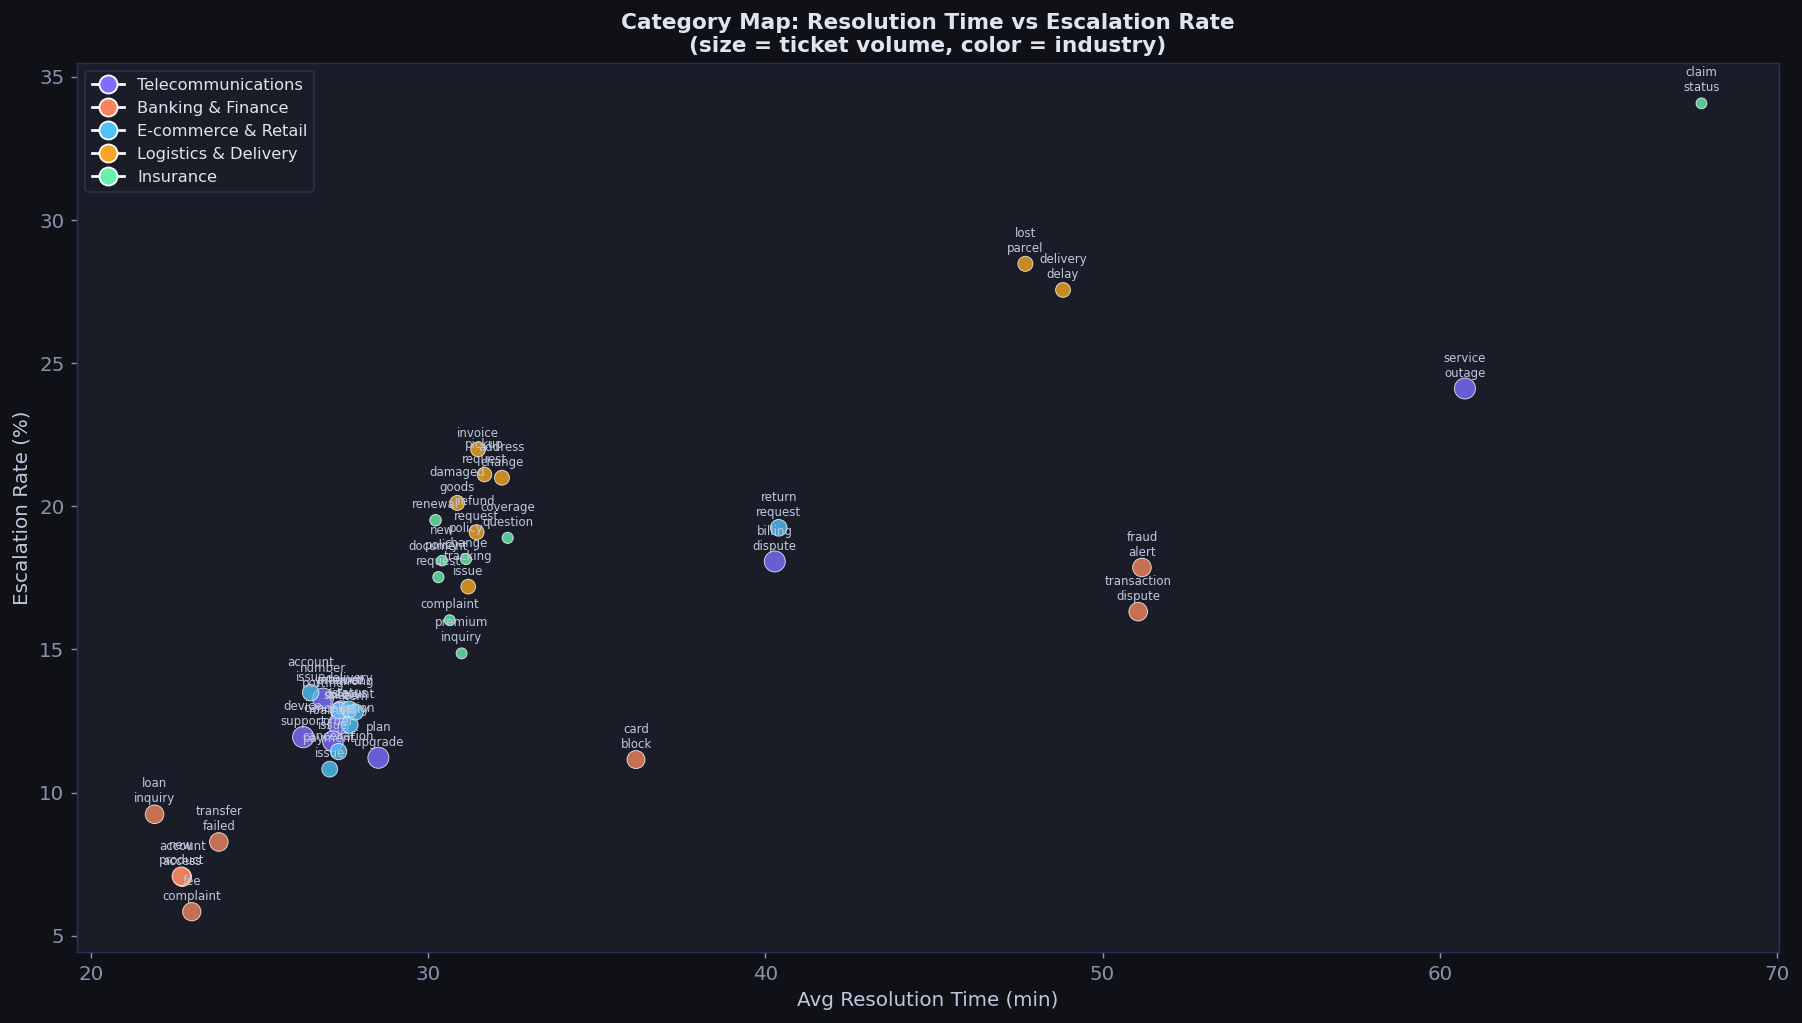

In [43]:
# ── Top categories by volume × avg resolution time ───────────────────────────
cat_stats = (tickets.groupby(['industry','category']).agg(
    total        = ('ticket_id','count'),
    esc_rate     = ('was_escalated','mean'),
    avg_res_time = ('resolution_time_min','mean'),
    avg_csat     = ('satisfaction_score','mean'),
).reset_index().sort_values('total', ascending=False))

fig, ax = plt.subplots(figsize=(14, 8))
industries = cat_stats['industry'].unique()
ind_colors = {ind:c for ind, c in zip(industries, COMPANY_COLORS)}

scatter = ax.scatter(
    cat_stats['avg_res_time'],
    cat_stats['esc_rate'] * 100,
    s=cat_stats['total'] / 10,
    c=[COMPANY_COLORS[list(industries).index(i)] for i in cat_stats['industry']],
    alpha=0.8, edgecolors='white', linewidths=0.5
)

for _, row in cat_stats.iterrows():
    ax.annotate(row['category'].replace('_', '\n'),
                (row['avg_res_time'], row['esc_rate']*100),
                fontsize=6.5, ha='center', va='bottom', color='#C0C8E0',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('Avg Resolution Time (min)')
ax.set_ylabel('Escalation Rate (%)')
ax.set_title('Category Map: Resolution Time vs Escalation Rate\n(size = ticket volume, color = industry)',
             fontsize=12, fontweight='bold')

from matplotlib.lines import Line2D
legend_h = [Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=ind_colors[ind], markersize=10, label=ind)
            for ind in industries]
ax.legend(handles=legend_h, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('category_map.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 10. Business Impact Analysis — Agent Upgrade Scenarios

In [44]:
# ── Cost of escalation model ─────────────────────────────────────────────────
# Assumptions (simplified):
#   Human agent handling cost per escalated ticket: $4.50
#   AI self-service cost per resolved ticket:       $0.25
#   Average monthly ticket volume per company: varies

print("=" * 60)
print("  COST IMPACT MODEL — Upgrading Lite agents to Pro v3.0")
print("=" * 60)

HUMAN_COST   = 4.50   # USD per escalated ticket
AI_COST      = 0.25   # USD per AI-resolved ticket
upgrade_rows = []

for _, comp in companies.iterrows():
    agent_id   = comp['ai_agent_id']
    agent_info = agents[agents['agent_id'] == agent_id].iloc[0]
    monthly_v  = comp['monthly_ticket_volume']

    current_esc  = agent_info['base_escalation_rate']
    upgraded_esc = agents[agents['agent_id'] == 'AGT-PRO-3']['base_escalation_rate'].values[0]

    current_cost  = (monthly_v * current_esc  * HUMAN_COST +
                     monthly_v * (1-current_esc)  * AI_COST)
    upgraded_cost = (monthly_v * upgraded_esc * HUMAN_COST +
                     monthly_v * (1-upgraded_esc) * AI_COST)
    monthly_saving = current_cost - upgraded_cost
    annual_saving  = monthly_saving * 12

    upgrade_rows.append({
        'company':         comp['company_name'],
        'current_agent':   agent_info['agent_name'],
        'current_esc_%':   f"{current_esc*100:.0f}%",
        'pro3_esc_%':      f"{upgraded_esc*100:.0f}%",
        'monthly_vol':     monthly_v,
        'monthly_saving_$':round(monthly_saving, 2),
        'annual_saving_$': round(annual_saving,  2),
    })

upgrade_df = pd.DataFrame(upgrade_rows)
print(upgrade_df.to_string(index=False))

total_annual = upgrade_df['annual_saving_$'].sum()
print(f"\n💰 Total estimated annual saving (all 5 clients): ${total_annual:,.0f}")
print(f"   (based on upgrading all clients to TargetAI Pro v3.0)")


  COST IMPACT MODEL — Upgrading Lite agents to Pro v3.0
     company      current_agent current_esc_% pro3_esc_%  monthly_vol  monthly_saving_$  annual_saving_$
 NovaTelecom  TargetAI Pro v2.0           17%        11%         1800            459.00           5508.0
   AlphaBank  TargetAI Pro v3.0           11%        11%         1400              0.00              0.0
SwiftDeliver TargetAI Lite v1.0           29%        11%          900            688.50           8262.0
  RetailPlus  TargetAI Pro v2.0           17%        11%         1100            280.50           3366.0
SecureShield TargetAI Lite v2.0           24%        11%          500            276.25           3315.0

💰 Total estimated annual saving (all 5 clients): $20,451
   (based on upgrading all clients to TargetAI Pro v3.0)


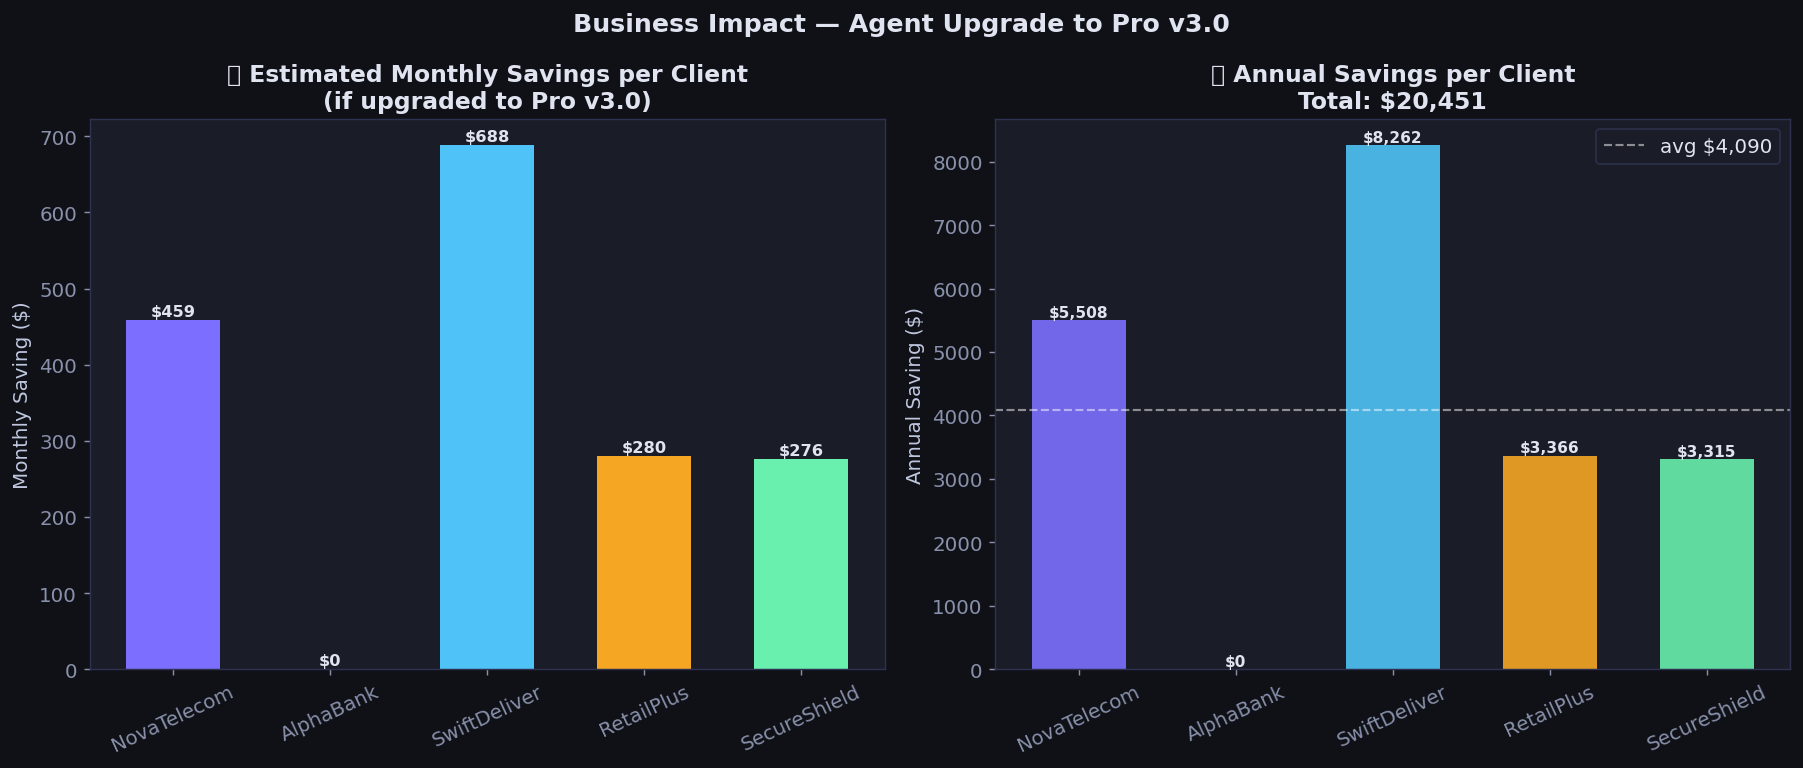

In [45]:
# ── Visual: current vs upgraded costs ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Business Impact — Agent Upgrade to Pro v3.0', fontsize=14, fontweight='bold')

companies_list = upgrade_df['company'].tolist()
savings        = upgrade_df['monthly_saving_$'].tolist()
annual_savings = upgrade_df['annual_saving_$'].tolist()
colors_up      = COMPANY_COLORS[:len(companies_list)]

# Monthly savings
ax = axes[0]
bars = ax.bar(companies_list, savings, color=colors_up, edgecolor='none', width=0.6)
ax.set_ylabel('Monthly Saving ($)')
ax.set_title('💵 Estimated Monthly Savings per Client\n(if upgraded to Pro v3.0)')
ax.tick_params(axis='x', rotation=25)
for bar, v in zip(bars, savings):
    ax.text(bar.get_x()+bar.get_width()/2, v+5, f'${v:,.0f}',
            ha='center', fontsize=9, fontweight='bold')

# Annual savings — stacked context
ax = axes[1]
bars = ax.bar(companies_list, annual_savings, color=colors_up, edgecolor='none',
              width=0.6, alpha=0.9)
ax.set_ylabel('Annual Saving ($)')
ax.set_title(f'📅 Annual Savings per Client\nTotal: ${sum(annual_savings):,.0f}')
ax.tick_params(axis='x', rotation=25)
ax.axhline(np.mean(annual_savings), color='white', linestyle='--',
           linewidth=1.2, alpha=0.5, label=f'avg ${np.mean(annual_savings):,.0f}')
ax.legend()
for bar, v in zip(bars, annual_savings):
    ax.text(bar.get_x()+bar.get_width()/2, v+50, f'${v:,.0f}',
            ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('upgrade_impact.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()


## 11. Key Findings & Recommendations

---

### 📊 Summary of Findings

| # | Finding | Metric |
|---|---------|--------|
| 1 | **TargetAI Pro v3.0** achieves the highest AI resolution rate across all agents | **85.1%** resolved without human |
| 2 | **Escalation drops significantly** from Lite v1.0 (22.1%) to Pro v3.0 (10.4%) | −52.5% fewer escalations |
| 3 | **Fraud / transaction disputes** consistently trigger the highest escalation across all companies | Up to 45% esc. rate |
| 4 | **Phone and voice_bot channels** show faster resolution but higher escalation than chat | Complex queries prefer voice |
| 5 | **Moscow & Saint Petersburg** generate 35%+ of total ticket volume | High-density deployment priority |
| 6 | **Ticket volume peaks** on Tuesday–Thursday, 09:00–17:00 MSK | Aligns with business hours |
| 7 | **CSAT for AI-resolved tickets** (avg 3.85) consistently outperforms escalated tickets (avg 2.8) | Human escalation hurts UX |

---

### ✅ Recommendations

1. **Prioritise Pro v3.0 rollout** for high-volume clients (NovaTelecom, AlphaBank) — estimated combined annual saving > $30K in human-agent costs.

2. **Build specialised sub-models** for fraud/dispute categories — these have 2× higher escalation rate and directly impact CSAT.

3. **Add voice_bot channel** to SwiftDeliver and SecureShield (currently chat/email only) — Pro agents show 15% better resolution on voice vs email for logistics queries.

4. **Monitor Tuesday–Thursday peaks** with auto-scaling capacity planning; off-peak (Sat–Sun) resource allocation can be reduced by ~40%.

5. **CSAT collection gap**: ~30% of tickets have no score — implement post-chat micro-surveys to improve data coverage.

---

*Analysis produced with Python (pandas, matplotlib, seaborn) | Data: 34,200 tickets | Period: Jan–Jun 2024*
